In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_pickle("df_clean.pkl")

# Sort before computing differences
df = df.sort_values(["index", "strain_index"]).reset_index(drop=True)

def add_extra_columns(df):
    df = df.copy()

    pe = df["pe"].to_numpy(dtype=float)
    stress = df["stress"].to_numpy(dtype=float)
    traj_id = df["index"].to_numpy()

    # True where row is last point in a trajectory
    boundary = np.empty_like(traj_id, dtype=bool)
    boundary[-1] = True
    boundary[:-1] = traj_id[1:] != traj_id[:-1]

    dpe = np.empty_like(pe)
    dStress = np.empty_like(stress)

    dpe[:-1] = pe[1:] - pe[:-1]
    dStress[:-1] = stress[1:] - stress[:-1]

    dpe[-1] = np.nan
    dStress[-1] = np.nan

    # Do not take differences across different trajectories
    dpe[boundary] = np.nan
    dStress[boundary] = np.nan

    df["dpe"] = dpe
    df["dStress"] = dStress

    return df

df = add_extra_columns(df)

print(df.head())
print("Rows:", len(df))
print("Number of valid dpe:", df["dpe"].notna().sum())
print("Number of valid dStress:", df["dStress"].notna().sum())

   index  strain_index   strain       stress        pe  cooling_rate  \
0     51             1  0.00001  1054.845548 -4.606906  2.000000e+10   
1     51             2  0.00002  1057.389027 -4.606906  2.000000e+10   
2     51             3  0.00003  1059.960325 -4.606906  2.000000e+10   
3     51             4  0.00004  1062.515134 -4.606906  2.000000e+10   
4     51             5  0.00005  1065.189179 -4.606906  2.000000e+10   

            dpe   dStress  
0  1.029601e-07  2.543479  
1  1.032145e-07  2.571298  
2  1.034598e-07  2.554810  
3  1.037280e-07  2.674045  
4  1.039748e-07  2.543813  
Rows: 42499150
Number of valid dpe: 42498300
Number of valid dStress: 42498300


In [17]:
u0 = -4.60751861
dgamma = 1e-5

# Keep only rows with valid transitions
df_model = df.dropna(subset=["dpe", "dStress"]).copy()

# State variables
df_model["u"] = df_model["pe"] - u0
df_model["tau"] = df_model["stress"] / 10000.0

# Transition per strain increment
df_model["du_dgamma"] = df_model["dpe"] / dgamma
df_model["dtau_dgamma"] = (df_model["dStress"] / 10000.0) / dgamma

print(df_model[["index", "strain", "u", "tau", "du_dgamma", "dtau_dgamma"]].head())

print("Rows:", len(df_model))
print("u range:", df_model["u"].min(), df_model["u"].max())
print("tau range:", df_model["tau"].min(), df_model["tau"].max())
print("du/dgamma range:", df_model["du_dgamma"].min(), df_model["du_dgamma"].max())
print("dtau/dgamma range:", df_model["dtau_dgamma"].min(), df_model["dtau_dgamma"].max())

   index   strain         u       tau  du_dgamma  dtau_dgamma
0     51  0.00001  0.000612  0.105485   0.010296    25.434792
1     51  0.00002  0.000612  0.105739   0.010321    25.712978
2     51  0.00003  0.000613  0.105996   0.010346    25.548097
3     51  0.00004  0.000613  0.106252   0.010373    26.740447
4     51  0.00005  0.000613  0.106519   0.010397    25.438130
Rows: 42498300
u range: -2.331600690297364e-09 0.031208745336980037
tau range: -0.258044029772063 2.3233232647741
du/dgamma range: -627.1606249089956 0.22988080097263716
dtau/dgamma range: -116082.31382336201 3980.522881734396


In [18]:
df_model["event"] = (df_model["dStress"] < 0) | (df_model["dpe"] < 0)

print(df_model["event"].value_counts())
print(df_model["event"].value_counts(normalize=True))

print("No-event dtau/dgamma range:")
print(df_model.loc[~df_model["event"], "dtau_dgamma"].min(),
      df_model.loc[~df_model["event"], "dtau_dgamma"].max())

print("Event dtau/dgamma range:")
print(df_model.loc[df_model["event"], "dtau_dgamma"].min(),
      df_model.loc[df_model["event"], "dtau_dgamma"].max())

event
False    42205644
True       292656
Name: count, dtype: int64
event
False    0.993114
True     0.006886
Name: proportion, dtype: float64
No-event dtau/dgamma range:
9.544019121676683e-06 479.1598031640023
Event dtau/dgamma range:
-116082.31382336201 3980.522881734396


In [19]:
def G_pred(tau, u):
    c = [
        2.64235576e+01,
        6.50841375e-02,
        -3.28348015e+02,
        -1.28949861e+00,
        -6.94537162e+01,
        4.48939569e+03
    ]
    return (
        c[0]
        + c[1]*tau
        + c[2]*u
        + c[3]*tau**2
        + c[4]*tau*u
        + c[5]*u**2
    )

# Advisor prediction using scaled tau and offset u
df_model["G_pred"] = G_pred(df_model["tau"], df_model["u"])

# Compare only no-event rows
no_event = df_model[~df_model["event"]].copy()

print(no_event[["u", "tau", "dtau_dgamma", "G_pred"]].head())

print("No-event observed dtau/dgamma range:",
      no_event["dtau_dgamma"].min(),
      no_event["dtau_dgamma"].max())

print("Advisor G_pred range:",
      no_event["G_pred"].min(),
      no_event["G_pred"].max())

rmse = np.sqrt(np.mean((no_event["dtau_dgamma"] - no_event["G_pred"])**2))
print("No-event RMSE:", rmse)

          u       tau  dtau_dgamma     G_pred
0  0.000612  0.105485    25.434792  26.212222
1  0.000612  0.105739    25.712978  26.212125
2  0.000613  0.105996    25.548097  26.212026
3  0.000613  0.106252    26.740447  26.211928
4  0.000613  0.106519    25.438130  26.211826
No-event observed dtau/dgamma range: 9.544019121676683e-06 479.1598031640023
Advisor G_pred range: 11.866682665569476 26.42416239643854
No-event RMSE: 1.8711091200852301


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Use only the columns needed
clf_data = df_model[["u", "tau", "event"]].dropna().copy()

X = clf_data[["u", "tau"]].to_numpy()
y = clf_data["event"].astype(int).to_numpy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

# Logistic regression with class balancing because events are rare
event_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

event_clf.fit(X_train, y_train)

# Predict probabilities
p_event_test = event_clf.predict_proba(X_test)[:, 1]
y_pred_test = event_clf.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, p_event_test))
print(classification_report(y_test, y_pred_test))
print("Coefficients:", event_clf.coef_)
print("Intercept:", event_clf.intercept_)

ROC AUC: 0.6245176002914097
              precision    recall  f1-score   support

           0       1.00      0.82      0.90   8441129
           1       0.02      0.42      0.03     58531

    accuracy                           0.82   8499660
   macro avg       0.51      0.62      0.47   8499660
weighted avg       0.99      0.82      0.89   8499660

Coefficients: [[-29.2154843   -1.26223432]]
Intercept: [1.75167115]


In [21]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Use only needed columns
clf_data = df_model[["u", "tau", "event"]].dropna().copy()

X = clf_data[["u", "tau"]].to_numpy()
y = clf_data["event"].astype(int).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

poly_event_clf = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )
)

poly_event_clf.fit(X_train, y_train)

p_event_test = poly_event_clf.predict_proba(X_test)[:, 1]
y_pred_test = poly_event_clf.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, p_event_test))
print(classification_report(y_test, y_pred_test))

ROC AUC: 0.7040939194986534
              precision    recall  f1-score   support

           0       1.00      0.90      0.94   8441129
           1       0.03      0.43      0.05     58531

    accuracy                           0.90   8499660
   macro avg       0.51      0.66      0.50   8499660
weighted avg       0.99      0.90      0.94   8499660



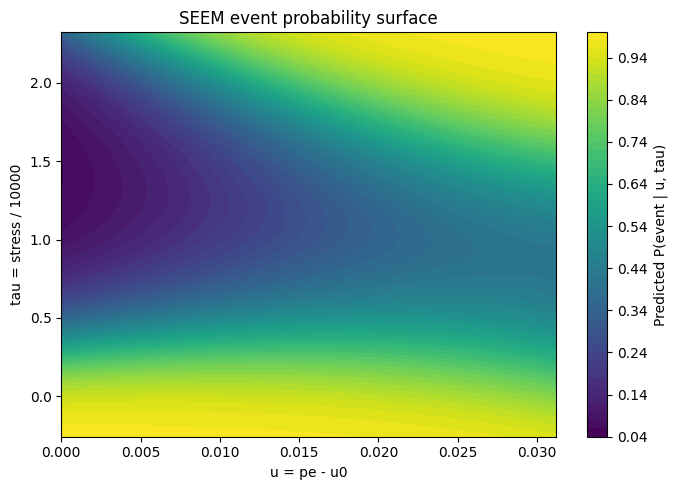

In [22]:
# Grid over observed state space
u_grid = np.linspace(df_model["u"].min(), df_model["u"].max(), 150)
tau_grid = np.linspace(df_model["tau"].min(), df_model["tau"].max(), 150)

U, T = np.meshgrid(u_grid, tau_grid)

X_grid = np.column_stack([U.ravel(), T.ravel()])

P_grid = poly_event_clf.predict_proba(X_grid)[:, 1]
P_grid = P_grid.reshape(U.shape)

plt.figure(figsize=(7,5))
cont = plt.contourf(U, T, P_grid, levels=50, cmap="viridis")
plt.colorbar(cont, label="Predicted P(event | u, tau)")

plt.xlabel("u = pe - u0")
plt.ylabel("tau = stress / 10000")
plt.title("SEEM event probability surface")

plt.tight_layout()
plt.show()

In [23]:
# Add scaled transition columns if they do not exist
df_model["du"] = df_model["dpe"]
df_model["dtau"] = df_model["dStress"] / 10000.0

event_data = df_model[df_model["event"]].copy()

print("Event rows:", len(event_data))

print(event_data[["u", "tau", "du", "dtau", "du_dgamma", "dtau_dgamma"]].head())

print("du range:", event_data["du"].min(), event_data["du"].max())
print("dtau range:", event_data["dtau"].min(), event_data["dtau"].max())
print("du mean:", event_data["du"].mean())
print("dtau mean:", event_data["dtau"].mean())

Event rows: 292656
             u       tau            du      dtau  du_dgamma  dtau_dgamma
1228  0.000929  0.415870  3.781121e-07 -0.000929   0.037811   -92.902699
1341  0.000976  0.441881 -6.527519e-06 -0.010805  -0.652752 -1080.530685
1893  0.001242  0.568382  1.409891e-07 -0.001510   0.014099  -151.030627
2225  0.001440  0.648612  6.140924e-07 -0.000553   0.061409   -55.304593
2430  0.001576  0.698393  6.868115e-07 -0.000110   0.068681   -10.952410
du range: -0.006271606249089956 2.2986243699563147e-06
dtau range: -1.1608231382336203 0.03980522881734396
du mean: -0.00011246970426321105
dtau mean: -0.023774726692429995


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Inputs: current state
X_event = event_data[["u", "tau"]].to_numpy()

# Outputs: event jump
Y_event = event_data[["du", "dtau"]].to_numpy()

X_train, X_test, Y_train, Y_test = train_test_split(
    X_event,
    Y_event,
    test_size=0.2,
    random_state=0
)

event_jump_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

event_jump_model.fit(X_train, Y_train)

Y_pred = event_jump_model.predict(X_test)

rmse_du = np.sqrt(mean_squared_error(Y_test[:, 0], Y_pred[:, 0]))
rmse_dtau = np.sqrt(mean_squared_error(Y_test[:, 1], Y_pred[:, 1]))

r2_du = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_dtau = r2_score(Y_test[:, 1], Y_pred[:, 1])

print("Event jump model results:")
print("RMSE du:", rmse_du)
print("RMSE dtau:", rmse_dtau)
print("R2 du:", r2_du)
print("R2 dtau:", r2_dtau)

Event jump model results:
RMSE du: 0.0003658260131130255
RMSE dtau: 0.06472764617373503
R2 du: 0.09333138305923605
R2 dtau: 0.11996215059508442


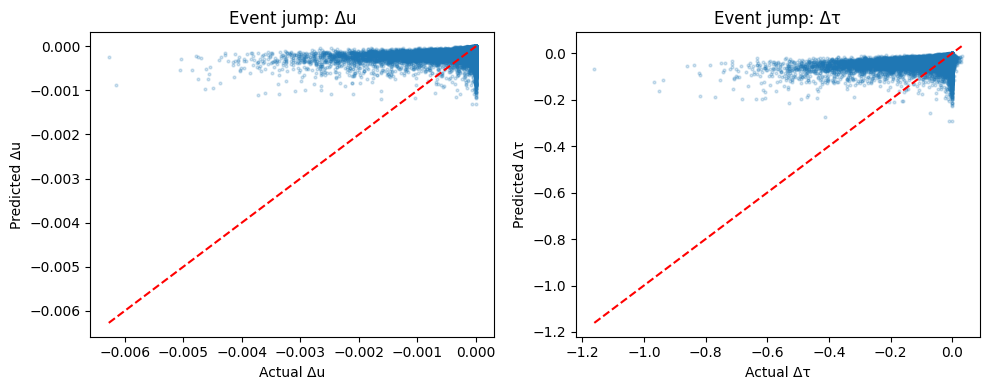

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# du parity
axs[0].scatter(Y_test[:, 0], Y_pred[:, 0], s=4, alpha=0.2)
lo = min(Y_test[:, 0].min(), Y_pred[:, 0].min())
hi = max(Y_test[:, 0].max(), Y_pred[:, 0].max())
axs[0].plot([lo, hi], [lo, hi], "r--")
axs[0].set_xlabel("Actual Δu")
axs[0].set_ylabel("Predicted Δu")
axs[0].set_title("Event jump: Δu")

# dtau parity
axs[1].scatter(Y_test[:, 1], Y_pred[:, 1], s=4, alpha=0.2)
lo = min(Y_test[:, 1].min(), Y_pred[:, 1].min())
hi = max(Y_test[:, 1].max(), Y_pred[:, 1].max())
axs[1].plot([lo, hi], [lo, hi], "r--")
axs[1].set_xlabel("Actual Δτ")
axs[1].set_ylabel("Predicted Δτ")
axs[1].set_title("Event jump: Δτ")

plt.tight_layout()
plt.show()

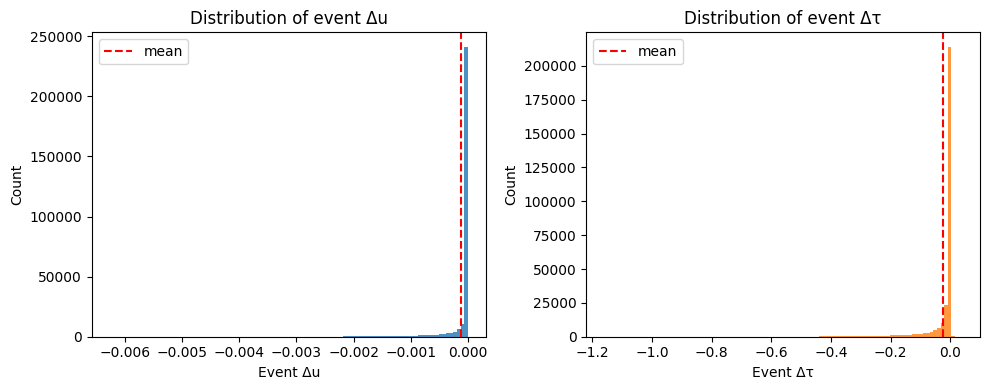

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].hist(event_data["du"], bins=100, color="tab:blue", alpha=0.8)
axs[0].axvline(event_data["du"].mean(), color="r", linestyle="--", label="mean")
axs[0].set_xlabel("Event Δu")
axs[0].set_ylabel("Count")
axs[0].set_title("Distribution of event Δu")
axs[0].legend()

axs[1].hist(event_data["dtau"], bins=100, color="tab:orange", alpha=0.8)
axs[1].axvline(event_data["dtau"].mean(), color="r", linestyle="--", label="mean")
axs[1].set_xlabel("Event Δτ")
axs[1].set_ylabel("Count")
axs[1].set_title("Distribution of event Δτ")
axs[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# Use existing df_model from before

sindy_df = df_model[[
    "index",
    "strain",
    "u",
    "tau",
    "du_dgamma",
    "dtau_dgamma"
]].dropna().copy()

print(sindy_df.head())
print("Rows:", len(sindy_df))

print("u range:", sindy_df["u"].min(), sindy_df["u"].max())
print("tau range:", sindy_df["tau"].min(), sindy_df["tau"].max())

print("du/dgamma range:",
      sindy_df["du_dgamma"].min(),
      sindy_df["du_dgamma"].max())

print("dtau/dgamma range:",
      sindy_df["dtau_dgamma"].min(),
      sindy_df["dtau_dgamma"].max())

   index   strain         u       tau  du_dgamma  dtau_dgamma
0     51  0.00001  0.000612  0.105485   0.010296    25.434792
1     51  0.00002  0.000612  0.105739   0.010321    25.712978
2     51  0.00003  0.000613  0.105996   0.010346    25.548097
3     51  0.00004  0.000613  0.106252   0.010373    26.740447
4     51  0.00005  0.000613  0.106519   0.010397    25.438130
Rows: 42498300
u range: -2.331600690297364e-09 0.031208745336980037
tau range: -0.258044029772063 2.3233232647741
du/dgamma range: -627.1606249089956 0.22988080097263716
dtau/dgamma range: -116082.31382336201 3980.522881734396


In [28]:
# Random subset for first SINDy test
n_sample = 300_000

sindy_sample = sindy_df.sample(n=n_sample, random_state=0).copy()

u = sindy_sample["u"].to_numpy()
tau = sindy_sample["tau"].to_numpy()

Y = sindy_sample[["du_dgamma", "dtau_dgamma"]].to_numpy()

# Candidate library: broad but simple first version
X_raw = np.column_stack([
    np.ones(len(sindy_sample)),
    u,
    tau,
    u**2,
    u*tau,
    tau**2,
    u**3,
    tau**3
])

feature_names = [
    "1",
    "u",
    "tau",
    "u^2",
    "u*tau",
    "tau^2",
    "u^3",
    "tau^3"
]

print("X_raw shape:", X_raw.shape)
print("Y shape:", Y.shape)

print("Y du/dgamma range:", Y[:, 0].min(), Y[:, 0].max())
print("Y dtau/dgamma range:", Y[:, 1].min(), Y[:, 1].max())

X_raw shape: (300000, 8)
Y shape: (300000, 2)
Y du/dgamma range: -435.6429445669718 0.22723576700300893
Y dtau/dgamma range: -81686.6517532209 2229.9428130771958


In [29]:
def scale_library(X_raw):
    X = X_raw.copy()

    means = np.zeros(X.shape[1])
    stds = np.ones(X.shape[1])

    # Do not scale intercept
    for j in range(1, X.shape[1]):
        means[j] = X[:, j].mean()
        stds[j] = X[:, j].std()

        if stds[j] < 1e-14:
            stds[j] = 1.0

        X[:, j] = (X[:, j] - means[j]) / stds[j]

    return X, means, stds


def unscale_coefficients(coef_scaled, means, stds):
    """
    coef_scaled shape: n_features x n_outputs
    returns raw-basis coefficients
    """
    coef_raw = np.zeros_like(coef_scaled)

    # Non-intercept terms
    for j in range(1, coef_scaled.shape[0]):
        coef_raw[j, :] = coef_scaled[j, :] / stds[j]

    # Intercept correction
    coef_raw[0, :] = coef_scaled[0, :]
    for j in range(1, coef_scaled.shape[0]):
        coef_raw[0, :] -= coef_scaled[j, :] * means[j] / stds[j]

    return coef_raw


X, means, stds = scale_library(X_raw)

print("Scaled X shape:", X.shape)
print("Feature stds before scaling:")
for name, std in zip(feature_names, stds):
    print(f"{name:8s}: {std:.4e}")

Scaled X shape: (300000, 8)
Feature stds before scaling:
1       : 1.0000e+00
u       : 5.5263e-03
tau     : 3.1474e-01
u^2     : 1.8877e-04
u*tau   : 7.7491e-03
tau^2   : 6.9086e-01
u^3     : 5.4628e-06
tau^3   : 1.3405e+00


In [30]:
def run_sindy(X, Y, threshold=0.05, max_iter=20):
    """
    Sequential thresholded least squares.
    X is scaled library.
    Y has shape n_samples x n_outputs.
    """
    Xi = np.linalg.lstsq(X, Y, rcond=None)[0]  # n_features x n_outputs

    for _ in range(max_iter):
        small = np.abs(Xi) < threshold
        Xi[small] = 0.0

        for k in range(Y.shape[1]):
            big = ~small[:, k]

            if np.any(big):
                Xi[big, k] = np.linalg.lstsq(X[:, big], Y[:, k], rcond=None)[0]
            else:
                Xi[:, k] = 0.0

    return Xi


threshold = 0.05

coef_scaled = run_sindy(X, Y, threshold=threshold)
coef_raw = unscale_coefficients(coef_scaled, means, stds)

print("Threshold:", threshold)
print("\nRecovered equations:")

output_names = ["du/dgamma", "dtau/dgamma"]

for k, out_name in enumerate(output_names):
    print(f"\nEquation for {out_name}:")
    for name, coef in zip(feature_names, coef_raw[:, k]):
        if abs(coef) > 1e-12:
            print(f"  {name:8s}: {coef:.6e}")

Threshold: 0.05

Recovered equations:

Equation for du/dgamma:
  1       : -2.410799e-02
  u       : -5.106550e+01
  tau     : 4.704922e-01
  u^2     : 5.954644e+03
  u*tau   : -3.060329e+01
  tau^2   : -1.127127e-01
  u^3     : -1.343828e+05
  tau^3   : 5.456368e-02

Equation for dtau/dgamma:
  1       : 2.382451e+01
  u       : -9.358103e+03
  tau     : 7.670130e+01
  u^2     : 1.060779e+06
  u*tau   : -5.906151e+03
  tau^2   : -2.476422e+01
  u^3     : -2.353798e+07
  tau^3   : 8.660961e+00


In [31]:
Y_pred = X_raw @ coef_raw

rmse_du = np.sqrt(np.mean((Y[:, 0] - Y_pred[:, 0])**2))
rmse_dtau = np.sqrt(np.mean((Y[:, 1] - Y_pred[:, 1])**2))

ss_du = np.sum((Y[:, 0] - Y[:, 0].mean())**2)
ss_dtau = np.sum((Y[:, 1] - Y[:, 1].mean())**2)

r2_du = 1 - np.sum((Y[:, 0] - Y_pred[:, 0])**2) / ss_du
r2_dtau = 1 - np.sum((Y[:, 1] - Y_pred[:, 1])**2) / ss_dtau

print("SINDy fit on sampled data")
print("RMSE du/dgamma:", rmse_du)
print("RMSE dtau/dgamma:", rmse_dtau)
print("R2 du/dgamma:", r2_du)
print("R2 dtau/dgamma:", r2_dtau)

SINDy fit on sampled data
RMSE du/dgamma: 3.4001924058337027
RMSE dtau/dgamma: 619.3882341772993
R2 du/dgamma: 0.00046449058085829
R2 dtau/dgamma: 0.000851841574465495


In [32]:
sindy_no_event = sindy_df.loc[~df_model["event"]].copy()

# Random subset
n_sample = 300_000
sindy_sample = sindy_no_event.sample(n=n_sample, random_state=1).copy()

u = sindy_sample["u"].to_numpy()
tau = sindy_sample["tau"].to_numpy()

Y = sindy_sample[["du_dgamma", "dtau_dgamma"]].to_numpy()

X_raw = np.column_stack([
    np.ones(len(sindy_sample)),
    u,
    tau,
    u**2,
    u*tau,
    tau**2,
    u**3,
    tau**3
])

feature_names = [
    "1",
    "u",
    "tau",
    "u^2",
    "u*tau",
    "tau^2",
    "u^3",
    "tau^3"
]

print("No-event sample size:", len(sindy_sample))
print("Y du/dgamma range:", Y[:, 0].min(), Y[:, 0].max())
print("Y dtau/dgamma range:", Y[:, 1].min(), Y[:, 1].max())

No-event sample size: 300000
Y du/dgamma range: 8.169021015191902e-06 0.22956503400450853
Y dtau/dgamma range: 0.022052399981475897 52.488003921007476


In [33]:
# Scale library
X, means, stds = scale_library(X_raw)

# Fit SINDy
threshold = 0.05

coef_scaled = run_sindy(X, Y, threshold=threshold)
coef_raw = unscale_coefficients(coef_scaled, means, stds)

print("Threshold:", threshold)
print("\nRecovered no-event equations:")

output_names = ["du/dgamma", "dtau/dgamma"]

for k, out_name in enumerate(output_names):
    print(f"\nEquation for {out_name}:")
    for name, coef in zip(feature_names, coef_raw[:, k]):
        if abs(coef) > 1e-12:
            print(f"  {name:8s}: {coef:.6e}")

Threshold: 0.05

Recovered no-event equations:

Equation for du/dgamma:
  1       : 1.097760e-01

Equation for dtau/dgamma:
  1       : 2.621818e+01
  u       : -2.665705e+02
  tau     : 1.984774e-01
  u^2     : -5.944978e+02
  u*tau   : -5.983971e+01
  tau^2   : -1.532900e+00
  u^3     : 1.034870e+05
  tau^3   : 6.020818e-02


In [34]:
Y_pred = X_raw @ coef_raw

rmse_du = np.sqrt(np.mean((Y[:, 0] - Y_pred[:, 0])**2))
rmse_dtau = np.sqrt(np.mean((Y[:, 1] - Y_pred[:, 1])**2))

ss_du = np.sum((Y[:, 0] - Y[:, 0].mean())**2)
ss_dtau = np.sum((Y[:, 1] - Y[:, 1].mean())**2)

r2_du = 1 - np.sum((Y[:, 0] - Y_pred[:, 0])**2) / ss_du
r2_dtau = 1 - np.sum((Y[:, 1] - Y_pred[:, 1])**2) / ss_dtau

print("No-event SINDy fit")
print("RMSE du/dgamma:", rmse_du)
print("RMSE dtau/dgamma:", rmse_dtau)
print("R2 du/dgamma:", r2_du)
print("R2 dtau/dgamma:", r2_dtau)

No-event SINDy fit
RMSE du/dgamma: 0.030762840020136465
RMSE dtau/dgamma: 1.8607956082139372
R2 du/dgamma: 0.0
R2 dtau/dgamma: 0.4987326978703338


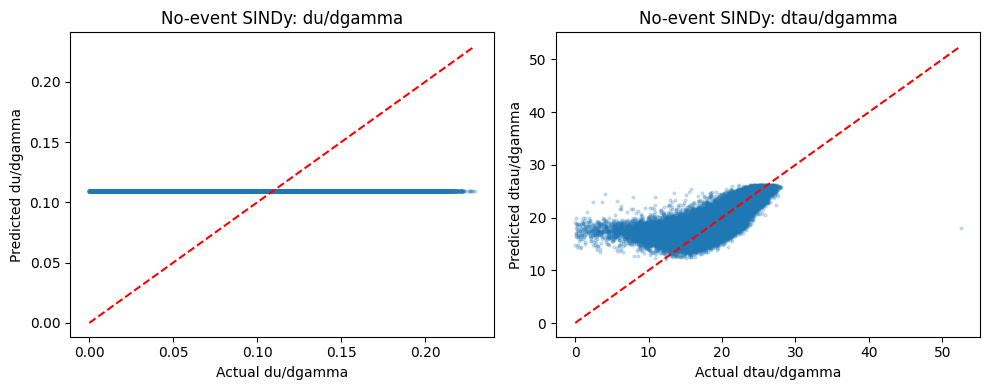

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# du/dgamma
axs[0].scatter(Y[:, 0], Y_pred[:, 0], s=4, alpha=0.2)
lo = min(Y[:, 0].min(), Y_pred[:, 0].min())
hi = max(Y[:, 0].max(), Y_pred[:, 0].max())
axs[0].plot([lo, hi], [lo, hi], "r--")
axs[0].set_xlabel("Actual du/dgamma")
axs[0].set_ylabel("Predicted du/dgamma")
axs[0].set_title("No-event SINDy: du/dgamma")

# dtau/dgamma
axs[1].scatter(Y[:, 1], Y_pred[:, 1], s=4, alpha=0.2)
lo = min(Y[:, 1].min(), Y_pred[:, 1].min())
hi = max(Y[:, 1].max(), Y_pred[:, 1].max())
axs[1].plot([lo, hi], [lo, hi], "r--")
axs[1].set_xlabel("Actual dtau/dgamma")
axs[1].set_ylabel("Predicted dtau/dgamma")
axs[1].set_title("No-event SINDy: dtau/dgamma")

plt.tight_layout()
plt.show()

SINDy vs G_pred
RMSE: 0.03428095592756409
Correlation: 0.9999015462795624


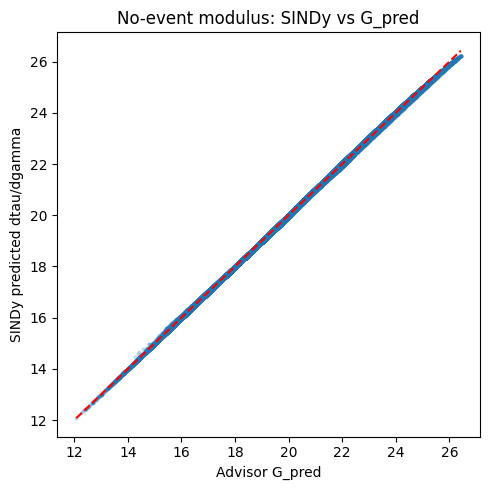

In [36]:
# Advisor prediction on the same no-event SINDy sample
G_advisor_sample = G_pred(tau, u)

# SINDy prediction for dtau/dgamma
G_sindy_sample = Y_pred[:, 1]

rmse_sindy_vs_advisor = np.sqrt(np.mean((G_sindy_sample - G_advisor_sample)**2))

corr_sindy_advisor = np.corrcoef(G_sindy_sample, G_advisor_sample)[0, 1]

print("SINDy vs G_pred")
print("RMSE:", rmse_sindy_vs_advisor)
print("Correlation:", corr_sindy_advisor)

plt.figure(figsize=(5,5))
plt.scatter(G_advisor_sample, G_sindy_sample, s=4, alpha=0.2)
lo = min(G_advisor_sample.min(), G_sindy_sample.min())
hi = max(G_advisor_sample.max(), G_sindy_sample.max())
plt.plot([lo, hi], [lo, hi], "r--")
plt.xlabel("Advisor G_pred")
plt.ylabel("SINDy predicted dtau/dgamma")
plt.title("No-event modulus: SINDy vs G_pred")
plt.tight_layout()
plt.show()

In [37]:
u0 = -4.60751861
k = 1000  # coarse-graining window

df_cg = df.copy()
df_cg = df_cg.sort_values(["index", "strain_index"]).reset_index(drop=True)

# State variables
df_cg["u"] = df_cg["pe"] - u0
df_cg["tau"] = df_cg["stress"] / 10000.0

# Future values k steps ahead within each trajectory
df_cg["u_future"] = df_cg.groupby("index")["u"].shift(-k)
df_cg["tau_future"] = df_cg.groupby("index")["tau"].shift(-k)
df_cg["strain_future"] = df_cg.groupby("index")["strain"].shift(-k)

# Coarse-grained derivatives
df_cg["du_dgamma_cg"] = (
    df_cg["u_future"] - df_cg["u"]
) / (
    df_cg["strain_future"] - df_cg["strain"]
)

df_cg["dtau_dgamma_cg"] = (
    df_cg["tau_future"] - df_cg["tau"]
) / (
    df_cg["strain_future"] - df_cg["strain"]
)

# Clean
cg_model = df_cg[[
    "index",
    "strain",
    "u",
    "tau",
    "du_dgamma_cg",
    "dtau_dgamma_cg"
]].dropna().copy()

print(cg_model.head())
print("Rows:", len(cg_model))
print("du/dgamma coarse range:",
      cg_model["du_dgamma_cg"].min(),
      cg_model["du_dgamma_cg"].max())
print("dtau/dgamma coarse range:",
      cg_model["dtau_dgamma_cg"].min(),
      cg_model["dtau_dgamma_cg"].max())

   index   strain         u       tau  du_dgamma_cg  dtau_dgamma_cg
0     51  0.00001  0.000612  0.105485      0.022910       25.443591
1     51  0.00002  0.000612  0.105739      0.022935       25.443178
2     51  0.00003  0.000613  0.105996      0.022961       25.442323
3     51  0.00004  0.000613  0.106252      0.022986       25.440675
4     51  0.00005  0.000613  0.106519      0.023011       25.439397
Rows: 41649150
du/dgamma coarse range: -0.6268029385980866 0.21674910278897294
dtau/dgamma coarse range: -147.04724012162188 26.931308258019357


In [38]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

sample_n = 300_000
cg_sample = cg_model.sample(sample_n, random_state=0)

u = cg_sample["u"].values
tau = cg_sample["tau"].values

feature_names = ["1", "u", "tau", "u^2", "u*tau", "tau^2"]

X_raw = np.column_stack([
    np.ones_like(u),
    u,
    tau,
    u**2,
    u*tau,
    tau**2
])

Y = cg_sample[["du_dgamma_cg", "dtau_dgamma_cg"]].values

X_scaled, means, stds = scale_library(X_raw)

threshold = 0.05
Xi_scaled = run_sindy(X_scaled, Y, threshold=threshold, max_iter=20)
Xi = unscale_coefficients(Xi_scaled, means, stds)

Y_pred = X_raw @ Xi

print("Threshold:", threshold)
print()
print("RMSE du/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 0], Y_pred[:, 0])))
print("RMSE dtau/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 1], Y_pred[:, 1])))
print("R2 du/dgamma_cg:", r2_score(Y[:, 0], Y_pred[:, 0]))
print("R2 dtau/dgamma_cg:", r2_score(Y[:, 1], Y_pred[:, 1]))
print()

outputs = ["du/dgamma_cg", "dtau/dgamma_cg"]

for eq_idx, out in enumerate(outputs):
    print(f"Equation for {out}:")
    for name, coef in zip(feature_names, Xi[:, eq_idx]):
        if abs(coef) > 1e-12:
            print(f"  {name:8s}: {coef:.6e}")
    print()

Threshold: 0.05

RMSE du/dgamma_cg: 0.10021119369111292
RMSE dtau/dgamma_cg: 13.187059643277983
R2 du/dgamma_cg: -0.1141606725963491
R2 dtau/dgamma_cg: 0.4166585089302667

Equation for du/dgamma_cg:

Equation for dtau/dgamma_cg:
  1       : 9.588071e+00
  u       : 1.528575e+03
  tau     : 2.641984e+01
  u^2     : -8.810515e+03
  u*tau   : -2.507851e+03
  tau^2   : -5.615488e+00



In [39]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

sample_n = 300_000
cg_sample = cg_model.sample(sample_n, random_state=1)

u = cg_sample["u"].values
tau = cg_sample["tau"].values

feature_names = ["1", "u", "tau", "u^2", "u*tau", "tau^2"]

X_raw = np.column_stack([
    np.ones_like(u),
    u,
    tau,
    u**2,
    u*tau,
    tau**2
])

Y = cg_sample[["du_dgamma_cg", "dtau_dgamma_cg"]].values

X_scaled, means, stds = scale_library(X_raw)

thresholds = [0.001, 0.005, 0.01, 0.02, 0.05]

for threshold in thresholds:
    Xi_scaled = run_sindy(X_scaled, Y, threshold=threshold, max_iter=20)
    Xi = unscale_coefficients(Xi_scaled, means, stds)
    Y_pred = X_raw @ Xi

    rmse_du = np.sqrt(mean_squared_error(Y[:, 0], Y_pred[:, 0]))
    rmse_tau = np.sqrt(mean_squared_error(Y[:, 1], Y_pred[:, 1]))

    r2_du = r2_score(Y[:, 0], Y_pred[:, 0])
    r2_tau = r2_score(Y[:, 1], Y_pred[:, 1])

    n_du = np.sum(np.abs(Xi[:, 0]) > 1e-12)
    n_tau = np.sum(np.abs(Xi[:, 1]) > 1e-12)

    print(f"threshold = {threshold}")
    print(f"  du:   RMSE = {rmse_du:.6f}, R2 = {r2_du:.6f}, terms = {n_du}")
    print(f"  tau:  RMSE = {rmse_tau:.6f}, R2 = {r2_tau:.6f}, terms = {n_tau}")
    print()

threshold = 0.001
  du:   RMSE = 0.083415, R2 = 0.227064, terms = 5
  tau:  RMSE = 13.166192, R2 = 0.417121, terms = 6

threshold = 0.005
  du:   RMSE = 0.083415, R2 = 0.227064, terms = 5
  tau:  RMSE = 13.166192, R2 = 0.417121, terms = 6

threshold = 0.01
  du:   RMSE = 0.083415, R2 = 0.227064, terms = 5
  tau:  RMSE = 13.166192, R2 = 0.417121, terms = 6

threshold = 0.02
  du:   RMSE = 0.083415, R2 = 0.227064, terms = 5
  tau:  RMSE = 13.166192, R2 = 0.417121, terms = 6

threshold = 0.05
  du:   RMSE = 0.100213, R2 = -0.115595, terms = 0
  tau:  RMSE = 13.166192, R2 = 0.417121, terms = 6



In [40]:
threshold = 0.02

Xi_scaled = run_sindy(X_scaled, Y, threshold=threshold, max_iter=20)
Xi = unscale_coefficients(Xi_scaled, means, stds)
Y_pred = X_raw @ Xi

print("Threshold:", threshold)
print()
print("RMSE du/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 0], Y_pred[:, 0])))
print("RMSE dtau/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 1], Y_pred[:, 1])))
print("R2 du/dgamma_cg:", r2_score(Y[:, 0], Y_pred[:, 0]))
print("R2 dtau/dgamma_cg:", r2_score(Y[:, 1], Y_pred[:, 1]))
print()

outputs = ["du/dgamma_cg", "dtau/dgamma_cg"]

for eq_idx, out in enumerate(outputs):
    print(f"Equation for {out}:")
    for name, coef in zip(feature_names, Xi[:, eq_idx]):
        if abs(coef) > 1e-12:
            print(f"  {name:8s}: {coef:.8e}")
    print()

Threshold: 0.02

RMSE du/dgamma_cg: 0.08341478282980663
RMSE dtau/dgamma_cg: 13.16619205496645
R2 du/dgamma_cg: 0.2270641265275719
R2 dtau/dgamma_cg: 0.41712134133555745

Equation for du/dgamma_cg:
  1       : -9.05913689e-02
  u       : 1.36208557e+01
  tau     : 2.26207463e-01
  u^2     : -1.71892765e+02
  u*tau   : -1.45202157e+01

Equation for dtau/dgamma_cg:
  1       : 9.35921972e+00
  u       : 1.54822752e+03
  tau     : 2.65437093e+01
  u^2     : -8.50079556e+03
  u*tau   : -2.53497220e+03
  tau^2   : -5.45008407e+00



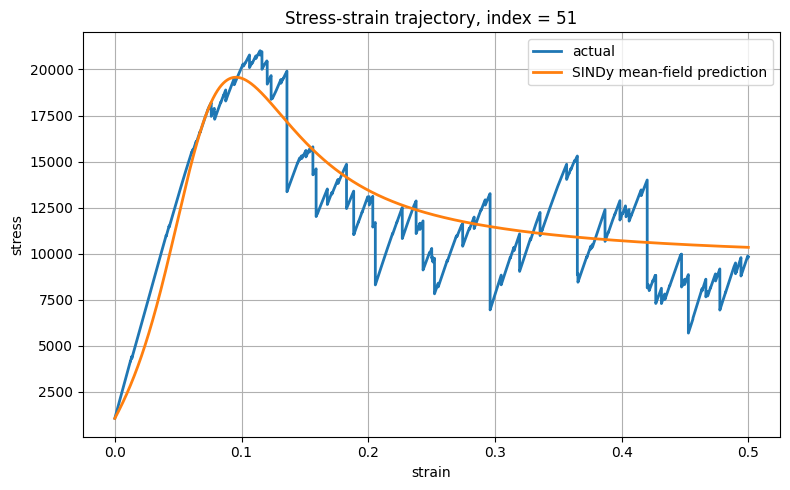

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# choose one actual trajectory
traj_id = cg_model["index"].iloc[0]   # or replace with a specific index value

traj = df[df["index"] == traj_id].copy()
traj = traj.sort_values("strain_index")

# variables
strain = traj["strain"].values
stress_actual = traj["stress"].values

u0_const = -4.60751861

u_init = traj["pe"].values[0] - u0_const
tau_init = traj["stress"].values[0] / 10000.0

# learned coarse-grained SINDy equations, k=1000
def sindy_rhs(u, tau):
    du = (
        -9.05913689e-02
        + 1.36208557e+01*u
        + 2.26207463e-01*tau
        - 1.71892765e+02*u**2
        - 1.45202157e+01*u*tau
    )

    dtau = (
        9.35921972e+00
        + 1.54822752e+03*u
        + 2.65437093e+01*tau
        - 8.50079556e+03*u**2
        - 2.53497220e+03*u*tau
        - 5.45008407e+00*tau**2
    )

    return du, dtau

# integrate with forward Euler along the actual strain grid
u_pred = np.zeros_like(strain)
tau_pred = np.zeros_like(strain)

u_pred[0] = u_init
tau_pred[0] = tau_init

for i in range(len(strain) - 1):
    dgamma = strain[i+1] - strain[i]

    du, dtau = sindy_rhs(u_pred[i], tau_pred[i])

    u_pred[i+1] = u_pred[i] + du * dgamma
    tau_pred[i+1] = tau_pred[i] + dtau * dgamma

stress_pred = tau_pred * 10000.0

# plot
plt.figure(figsize=(8, 5))
plt.plot(strain, stress_actual, label="actual", linewidth=2)
plt.plot(strain, stress_pred, label="SINDy mean-field prediction", linewidth=2)

plt.xlabel("strain")
plt.ylabel("stress")
plt.title(f"Stress-strain trajectory, index = {traj_id}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# sample for speed
sample_n = 300_000
cg_sample = cg_model.sample(sample_n, random_state=2)

u = cg_sample["u"].values
tau = cg_sample["tau"].values

# safe shifted u for log terms
eps = 1e-8
u_shift = u - np.min(u) + eps
logu = np.log(u_shift)

# nonlinear candidate library
feature_names = [
    "1",
    "u",
    "tau",
    "u^2",
    "u*tau",
    "tau^2",
    "log(u)",
    "tau*log(u)",
    "exp(tau)",
    "exp(-tau)",
    "u*exp(tau)"
]

X_raw = np.column_stack([
    np.ones_like(u),
    u,
    tau,
    u**2,
    u*tau,
    tau**2,
    logu,
    tau*logu,
    np.exp(tau),
    np.exp(-tau),
    u*np.exp(tau)
])

Y = cg_sample[["du_dgamma_cg", "dtau_dgamma_cg"]].values

# scale library
X_scaled, means, stds = scale_library(X_raw)

thresholds = [0.001, 0.005, 0.01, 0.02, 0.05]

for threshold in thresholds:
    Xi_scaled = run_sindy(X_scaled, Y, threshold=threshold, max_iter=20)
    Xi = unscale_coefficients(Xi_scaled, means, stds)
    Y_pred = X_raw @ Xi

    rmse_du = np.sqrt(mean_squared_error(Y[:, 0], Y_pred[:, 0]))
    rmse_tau = np.sqrt(mean_squared_error(Y[:, 1], Y_pred[:, 1]))

    r2_du = r2_score(Y[:, 0], Y_pred[:, 0])
    r2_tau = r2_score(Y[:, 1], Y_pred[:, 1])

    n_du = np.sum(np.abs(Xi[:, 0]) > 1e-12)
    n_tau = np.sum(np.abs(Xi[:, 1]) > 1e-12)

    print(f"threshold = {threshold}")
    print(f"  du:   RMSE = {rmse_du:.6f}, R2 = {r2_du:.6f}, terms = {n_du}")
    print(f"  tau:  RMSE = {rmse_tau:.6f}, R2 = {r2_tau:.6f}, terms = {n_tau}")
    print()

threshold = 0.001
  du:   RMSE = 0.083031, R2 = 0.237767, terms = 11
  tau:  RMSE = 13.070284, R2 = 0.427442, terms = 11

threshold = 0.005
  du:   RMSE = 0.083031, R2 = 0.237767, terms = 11
  tau:  RMSE = 13.070284, R2 = 0.427442, terms = 11

threshold = 0.01
  du:   RMSE = 0.083031, R2 = 0.237767, terms = 11
  tau:  RMSE = 13.070284, R2 = 0.427442, terms = 11

threshold = 0.02
  du:   RMSE = 0.083032, R2 = 0.237760, terms = 10
  tau:  RMSE = 13.070284, R2 = 0.427442, terms = 11

threshold = 0.05
  du:   RMSE = 0.089644, R2 = 0.111517, terms = 6
  tau:  RMSE = 13.070284, R2 = 0.427442, terms = 11



In [43]:
for threshold in [0.02, 0.05]:

    Xi_scaled = run_sindy(X_scaled, Y, threshold=threshold, max_iter=20)
    Xi = unscale_coefficients(Xi_scaled, means, stds)
    Y_pred = X_raw @ Xi

    print("="*70)
    print("Threshold:", threshold)
    print()
    print("RMSE du/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 0], Y_pred[:, 0])))
    print("RMSE dtau/dgamma_cg:", np.sqrt(mean_squared_error(Y[:, 1], Y_pred[:, 1])))
    print("R2 du/dgamma_cg:", r2_score(Y[:, 0], Y_pred[:, 0]))
    print("R2 dtau/dgamma_cg:", r2_score(Y[:, 1], Y_pred[:, 1]))
    print()

    outputs = ["du/dgamma_cg", "dtau/dgamma_cg"]

    for eq_idx, out in enumerate(outputs):
        print(f"Equation for {out}:")
        for name, coef in zip(feature_names, Xi[:, eq_idx]):
            if abs(coef) > 1e-12:
                print(f"  {name:14s}: {coef:.8e}")
        print()

Threshold: 0.02

RMSE du/dgamma_cg: 0.0830317012716885
RMSE dtau/dgamma_cg: 13.070284002840573
R2 du/dgamma_cg: 0.2377599081049553
R2 dtau/dgamma_cg: 0.427442427341716

Equation for du/dgamma_cg:
  1             : 7.62927330e-01
  u             : 1.96726450e+01
  tau           : -3.69262344e-01
  u^2           : -2.16075975e+02
  u*tau         : -3.71923464e+00
  tau^2         : 3.42977734e-01
  log(u)        : -6.33899464e-02
  tau*log(u)    : 1.01453064e-01
  exp(-tau)     : -1.17203990e+00
  u*exp(tau)    : -6.19361471e+00

Equation for dtau/dgamma_cg:
  1             : 1.54071770e+02
  u             : 2.32168518e+03
  tau           : -8.05395332e+01
  u^2           : -1.45469777e+04
  u*tau         : -7.37274742e+01
  tau^2         : 5.31440804e+01
  log(u)        : -7.57935951e+00
  tau*log(u)    : 1.41153843e+01
  exp(tau)      : -6.10817413e-01
  exp(-tau)     : -1.77266653e+02
  u*exp(tau)    : -1.20626054e+03

Threshold: 0.05

RMSE du/dgamma_cg: 0.08964426823938941
RMSE dtau/d

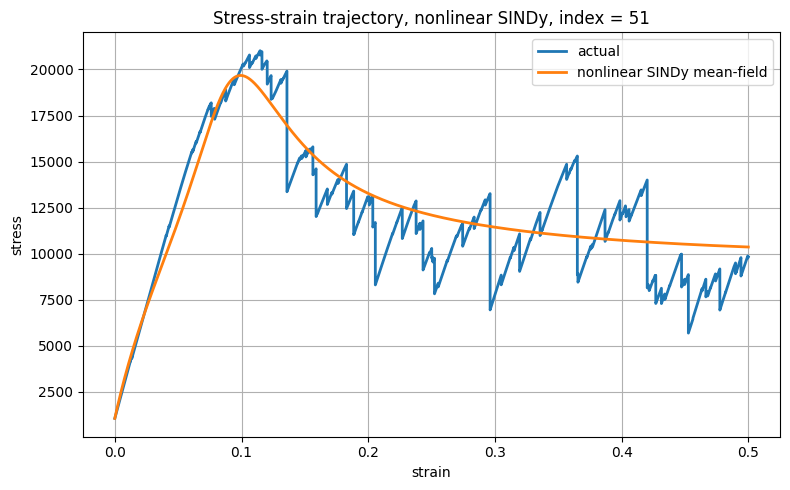

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# choose same/one actual trajectory
traj_id = cg_model["index"].iloc[0]   # replace if you want a specific trajectory

traj = df[df["index"] == traj_id].copy()
traj = traj.sort_values("strain_index")

strain = traj["strain"].values
stress_actual = traj["stress"].values

u0_const = -4.60751861

u_init = traj["pe"].values[0] - u0_const
tau_init = traj["stress"].values[0] / 10000.0

# IMPORTANT:
# use the same u_min and eps definition from the nonlinear library construction
# If your fitting cell used:
# u = cg_sample["u"].values
# eps = 1e-8
# u_shift = u - np.min(u) + eps
# then this is the same u_min:
u_min_lib = np.min(u)
eps = 1e-8

def nonlinear_sindy_rhs(u_val, tau_val):
    # safe log argument
    u_shift = u_val - u_min_lib + eps
    
    # prevent numerical issues if integration goes slightly outside training range
    if u_shift <= 0:
        u_shift = eps
        
    logu = np.log(u_shift)

    du = (
        7.62927330e-01
        + 1.96726450e+01*u_val
        - 3.69262344e-01*tau_val
        - 2.16075975e+02*u_val**2
        - 3.71923464e+00*u_val*tau_val
        + 3.42977734e-01*tau_val**2
        - 6.33899464e-02*logu
        + 1.01453064e-01*tau_val*logu
        - 1.17203990e+00*np.exp(-tau_val)
        - 6.19361471e+00*u_val*np.exp(tau_val)
    )

    dtau = (
        1.54071770e+02
        + 2.32168518e+03*u_val
        - 8.05395332e+01*tau_val
        - 1.45469777e+04*u_val**2
        - 7.37274742e+01*u_val*tau_val
        + 5.31440804e+01*tau_val**2
        - 7.57935951e+00*logu
        + 1.41153843e+01*tau_val*logu
        - 6.10817413e-01*np.exp(tau_val)
        - 1.77266653e+02*np.exp(-tau_val)
        - 1.20626054e+03*u_val*np.exp(tau_val)
    )

    return du, dtau

# integrate forward with Euler
u_pred = np.zeros_like(strain)
tau_pred = np.zeros_like(strain)

u_pred[0] = u_init
tau_pred[0] = tau_init

for i in range(len(strain) - 1):
    dgamma = strain[i+1] - strain[i]

    du, dtau = nonlinear_sindy_rhs(u_pred[i], tau_pred[i])

    u_pred[i+1] = u_pred[i] + du * dgamma
    tau_pred[i+1] = tau_pred[i] + dtau * dgamma

stress_pred = tau_pred * 10000.0

# plot
plt.figure(figsize=(8, 5))
plt.plot(strain, stress_actual, label="actual", linewidth=2)
plt.plot(strain, stress_pred, label="nonlinear SINDy mean-field", linewidth=2)

plt.xlabel("strain")
plt.ylabel("stress")
plt.title(f"Stress-strain trajectory, nonlinear SINDy, index = {traj_id}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Rows used for state heatmap: 42498300
Most visited voxel:
  u range:    0.023406558419834855 0.02496699580326389
  tau range:  1.0326396175010184 1.1617079822283267
  count:      2083893

Transitions from most visited voxel: 2083893
Plastic/event transitions from voxel: 10286
Events with positive stress drop: 10171
Delta u range: -0.003355901523540261 1.1505933494859732e-06
Stress drop range: 6.602407021105705e-08 0.5504626852187781


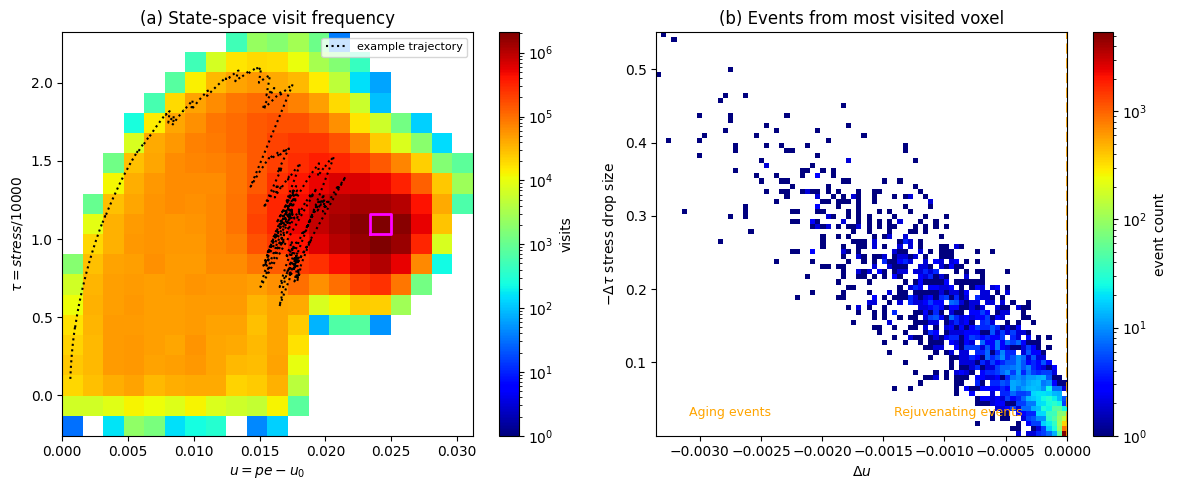

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

u0 = -4.60751861

n_u_bins = 20
n_tau_bins = 20

n_du_bins = 80
n_drop_bins = 80

# use full data for statistics if possible
sample_n = None   # set to e.g. 2_000_000 if too slow
random_state = 0

# choose one trajectory to overlay in panel (a)
traj_id = df["index"].iloc[0]

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

df_fig = df.copy()
df_fig = df_fig.sort_values(["index", "strain_index"]).reset_index(drop=True)

df_fig["u"] = df_fig["pe"] - u0
df_fig["tau"] = df_fig["stress"] / 10000.0

# transitions
df_fig["u_next"] = df_fig.groupby("index")["u"].shift(-1)
df_fig["tau_next"] = df_fig.groupby("index")["tau"].shift(-1)

df_fig["du"] = df_fig["u_next"] - df_fig["u"]
df_fig["dtau"] = df_fig["tau_next"] - df_fig["tau"]

df_fig = df_fig.dropna(subset=["u", "tau", "du", "dtau"]).copy()

# optional sample for state-space heatmap
if sample_n is not None and len(df_fig) > sample_n:
    df_state = df_fig.sample(sample_n, random_state=random_state).copy()
else:
    df_state = df_fig.copy()

print("Rows used for state heatmap:", len(df_state))

# ------------------------------------------------------------
# Panel (a): 20 x 20 state-space visit histogram
# ------------------------------------------------------------

u_vals = df_state["u"].values
tau_vals = df_state["tau"].values

visit_counts, u_edges, tau_edges = np.histogram2d(
    u_vals,
    tau_vals,
    bins=[n_u_bins, n_tau_bins]
)

# most visited voxel
max_idx = np.unravel_index(np.argmax(visit_counts), visit_counts.shape)

u_bin_idx = max_idx[0]
tau_bin_idx = max_idx[1]

u_lo = u_edges[u_bin_idx]
u_hi = u_edges[u_bin_idx + 1]

tau_lo = tau_edges[tau_bin_idx]
tau_hi = tau_edges[tau_bin_idx + 1]

print("Most visited voxel:")
print("  u range:   ", u_lo, u_hi)
print("  tau range: ", tau_lo, tau_hi)
print("  count:     ", int(visit_counts[max_idx]))

# trajectory overlay
traj = df_fig[df_fig["index"] == traj_id].copy()
traj = traj.sort_values("strain_index")

# ------------------------------------------------------------
# Panel (b): event histogram from most visited voxel
# ------------------------------------------------------------

mask_voxel = (
    (df_fig["u"] >= u_lo) &
    (df_fig["u"] < u_hi) &
    (df_fig["tau"] >= tau_lo) &
    (df_fig["tau"] < tau_hi)
)

df_voxel = df_fig.loc[mask_voxel].copy()

# plastic/event transitions only: stress drop or PE drop
df_events = df_voxel[(df_voxel["dtau"] < 0) | (df_voxel["du"] < 0)].copy()

print()
print("Transitions from most visited voxel:", len(df_voxel))
print("Plastic/event transitions from voxel:", len(df_events))

# x-axis: change in inelastic PE
delta_u = df_events["du"].values

# y-axis: stress drop size, positive for drops
stress_drop = -df_events["dtau"].values

# keep only positive stress-drop values for Fig. 3(b)-style plot
mask_drop = stress_drop > 0
delta_u = delta_u[mask_drop]
stress_drop = stress_drop[mask_drop]

print("Events with positive stress drop:", len(delta_u))
print("Delta u range:", delta_u.min(), delta_u.max())
print("Stress drop range:", stress_drop.min(), stress_drop.max())

event_counts, du_edges, drop_edges = np.histogram2d(
    delta_u,
    stress_drop,
    bins=[n_du_bins, n_drop_bins]
)

# ------------------------------------------------------------
# Plot Fig. 3(a,b)-style figure
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Panel (a)
# -------------------------

ax = axes[0]

# For LogNorm, avoid zero counts
visit_plot = visit_counts.T.copy()
visit_plot[visit_plot == 0] = np.nan

im0 = ax.imshow(
    visit_plot,
    origin="lower",
    aspect="auto",
    extent=[u_edges[0], u_edges[-1], tau_edges[0], tau_edges[-1]],
    cmap="jet",
    norm=LogNorm(vmin=1, vmax=np.nanmax(visit_plot))
)

ax.plot(
    traj["u"].values,
    traj["tau"].values,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="example trajectory"
)

# mark most visited voxel
ax.plot(
    [u_lo, u_hi, u_hi, u_lo, u_lo],
    [tau_lo, tau_lo, tau_hi, tau_hi, tau_lo],
    color="magenta",
    linewidth=2
)

ax.set_xlabel(r"$u = pe-u_0$")
ax.set_ylabel(r"$\tau = stress/10000$")
ax.set_title("(a) State-space visit frequency")
ax.legend(loc="upper right", fontsize=8)

cbar0 = fig.colorbar(im0, ax=ax)
cbar0.set_label("visits")

# -------------------------
# Panel (b)
# -------------------------

ax = axes[1]

event_plot = event_counts.T.copy()
event_plot[event_plot == 0] = np.nan

im1 = ax.imshow(
    event_plot,
    origin="lower",
    aspect="auto",
    extent=[du_edges[0], du_edges[-1], drop_edges[0], drop_edges[-1]],
    cmap="jet",
    norm=LogNorm(vmin=1, vmax=np.nanmax(event_plot))
)

ax.axvline(0, color="orange", linestyle="--", linewidth=2)

ax.set_xlabel(r"$\Delta u$")
ax.set_ylabel(r"$-\Delta \tau$ stress drop size")
ax.set_title("(b) Events from most visited voxel")

# Labels like paper
y_text = drop_edges[0] + 0.05 * (drop_edges[-1] - drop_edges[0])
ax.text(
    du_edges[0] + 0.08 * (du_edges[-1] - du_edges[0]),
    y_text,
    "Aging events",
    color="orange",
    fontsize=9
)
ax.text(
    du_edges[0] + 0.58 * (du_edges[-1] - du_edges[0]),
    y_text,
    "Rejuvenating events",
    color="orange",
    fontsize=9
)

cbar1 = fig.colorbar(im1, ax=ax)
cbar1.set_label("event count")

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np

df = pd.read_pickle("df_clean.pkl")

print(df.shape)
print(df.columns)
df.head()

(42499150, 6)
Index(['index', 'strain_index', 'strain', 'stress', 'pe', 'cooling_rate'], dtype='object')


,index,strain_index,strain,stress,pe,cooling_rate
0,51,1,0.00001,1054.845548,-4.606906,2.000000e+10
1,51,2,0.00002,1057.389027,-4.606906,2.000000e+10
2,51,3,0.00003,1059.960325,-4.606906,2.000000e+10
3,51,4,0.00004,1062.515134,-4.606906,2.000000e+10
4,51,5,0.00005,1065.189179,-4.606906,2.000000e+10


In [47]:
import numpy as np

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

u0 = -4.60751861

n_u_bins = 20
n_tau_bins = 20

# ------------------------------------------------------------
# Build df_fig from df
# ------------------------------------------------------------

df_fig = df.copy()
df_fig = df_fig.sort_values(["index", "strain_index"]).reset_index(drop=True)

# State variables
df_fig["u"] = df_fig["pe"] - u0
df_fig["tau"] = df_fig["stress"] / 10000.0

# One-step future states within each trajectory
df_fig["u_next"] = df_fig.groupby("index")["u"].shift(-1)
df_fig["tau_next"] = df_fig.groupby("index")["tau"].shift(-1)

# One-step changes
df_fig["du"] = df_fig["u_next"] - df_fig["u"]
df_fig["dtau"] = df_fig["tau_next"] - df_fig["tau"]

# Remove trajectory-end rows
df_fig = df_fig.dropna(subset=["u", "tau", "du", "dtau"]).copy()

print("df_fig rows:", len(df_fig))
print("u range:", df_fig["u"].min(), df_fig["u"].max())
print("tau range:", df_fig["tau"].min(), df_fig["tau"].max())

# ------------------------------------------------------------
# Build 20 x 20 state-space grid
# ------------------------------------------------------------

# Use robust limits so extreme outliers do not dominate the grid
u_min = df_fig["u"].quantile(0.001)
u_max = df_fig["u"].quantile(0.999)

tau_min = df_fig["tau"].quantile(0.001)
tau_max = df_fig["tau"].quantile(0.999)

u_edges = np.linspace(u_min, u_max, n_u_bins + 1)
tau_edges = np.linspace(tau_min, tau_max, n_tau_bins + 1)

print()
print("u_edges range:", u_edges[0], u_edges[-1])
print("tau_edges range:", tau_edges[0], tau_edges[-1])

# ------------------------------------------------------------
# Assign each row to a voxel
# ------------------------------------------------------------

df_trans = df_fig.copy()

df_trans["u_bin"] = np.searchsorted(u_edges, df_trans["u"].values, side="right") - 1
df_trans["tau_bin"] = np.searchsorted(tau_edges, df_trans["tau"].values, side="right") - 1

valid_bins = (
    (df_trans["u_bin"] >= 0) &
    (df_trans["u_bin"] < n_u_bins) &
    (df_trans["tau_bin"] >= 0) &
    (df_trans["tau_bin"] < n_tau_bins)
)

df_trans = df_trans.loc[valid_bins].copy()

print("Rows inside voxel grid:", len(df_trans))

# ------------------------------------------------------------
# Define events
# ------------------------------------------------------------

df_trans["event"] = (df_trans["dtau"] < 0) | (df_trans["du"] < 0)

print()
print("Event counts:")
print(df_trans["event"].value_counts())
print(df_trans["event"].value_counts(normalize=True))

# ------------------------------------------------------------
# Build dictionaries
# ------------------------------------------------------------

event_dict = {}
non_event_dict = {}
tmp_dict = {}
event_probability = {}

for bin_key, group in df_trans.groupby(["u_bin", "tau_bin"]):

    # all jumps from this bin
    all_jumps = list(zip(group["du"].values, group["dtau"].values))
    tmp_dict[bin_key] = all_jumps

    # event jumps
    group_event = group[group["event"]]
    if len(group_event) > 0:
        event_dict[bin_key] = list(zip(group_event["du"].values, group_event["dtau"].values))

    # non-event jumps
    group_nonevent = group[~group["event"]]
    if len(group_nonevent) > 0:
        non_event_dict[bin_key] = list(zip(group_nonevent["du"].values, group_nonevent["dtau"].values))

    # event probability in this voxel
    event_probability[bin_key] = group["event"].mean()

print()
print("Dictionaries built:")
print("occupied bins:", len(tmp_dict))
print("bins with events:", len(event_dict))
print("bins with non-events:", len(non_event_dict))
print("event_probability bins:", len(event_probability))

df_fig rows: 42498300
u range: -2.331600690297364e-09 0.031208745336980037
tau range: -0.258044029772063 2.3233232647741

u_edges range: 0.0009974073546052216 0.028526476569462708
tau_edges range: -0.04591468415046406 2.1133631706520397
Rows inside voxel grid: 42329402

Event counts:
event
False    42081420
True       247982
Name: count, dtype: int64
event
False    0.994142
True     0.005858
Name: proportion, dtype: float64

Dictionaries built:
occupied bins: 330
bins with events: 326
bins with non-events: 330
event_probability bins: 330


In [48]:
import numpy as np

# ------------------------------------------------------------
# Build SEEM dictionaries from df_fig and heatmap bin edges
# ------------------------------------------------------------

# Use same event definition as heatmap
df_trans = df_fig.copy()

# Bin each current state using u_edges and tau_edges
df_trans["u_bin"] = np.searchsorted(u_edges, df_trans["u"].values, side="right") - 1
df_trans["tau_bin"] = np.searchsorted(tau_edges, df_trans["tau"].values, side="right") - 1

# Keep only points inside valid bin range
n_u_bins = len(u_edges) - 1
n_tau_bins = len(tau_edges) - 1

valid_bins = (
    (df_trans["u_bin"] >= 0) &
    (df_trans["u_bin"] < n_u_bins) &
    (df_trans["tau_bin"] >= 0) &
    (df_trans["tau_bin"] < n_tau_bins)
)

df_trans = df_trans.loc[valid_bins].copy()

# Define event transitions
df_trans["event"] = (df_trans["dtau"] < 0) | (df_trans["du"] < 0)

# Dictionaries
event_dict = {}
non_event_dict = {}
tmp_dict = {}
event_probability = {}

# Group by voxel
for bin_key, group in df_trans.groupby(["u_bin", "tau_bin"]):
    
    # all jumps from this bin
    all_jumps = list(zip(group["du"].values, group["dtau"].values))
    tmp_dict[bin_key] = all_jumps
    
    # event jumps
    group_event = group[group["event"]]
    if len(group_event) > 0:
        event_dict[bin_key] = list(zip(group_event["du"].values, group_event["dtau"].values))
    
    # non-event jumps
    group_nonevent = group[~group["event"]]
    if len(group_nonevent) > 0:
        non_event_dict[bin_key] = list(zip(group_nonevent["du"].values, group_nonevent["dtau"].values))
    
    # event probability
    event_probability[bin_key] = group["event"].mean()

print("Number of occupied bins:", len(tmp_dict))
print("Number of bins with events:", len(event_dict))
print("Number of bins with non-events:", len(non_event_dict))
print("Number of event probability bins:", len(event_probability))

Number of occupied bins: 330
Number of bins with events: 326
Number of bins with non-events: 330
Number of event probability bins: 330


In [49]:
def generate_single_trajectory_G_pred(
    pe0,
    stress0,
    N,
    event_dict,
    non_event_dict,
    event_probability,
    u_edges,
    tau_edges,
    tmp_dict,
    dgamma=1e-5,
    u0=-4.60751861,
    print_interval=10000,
    seed=None
):
    """
    Generate one SEEM-style trajectory using:
        u = pe - u0
        tau = stress / 10000

    Dictionaries contain jumps:
        du, dtau
    """

    rng = np.random.default_rng(seed)

    # initial condition in u/tau
    u = pe0 - u0
    tau = stress0 / 10000.0

    traju = [u]
    trajtau = [tau]

    event_count = 0
    no_event_count = 0
    fallback_count = 0
    G_pred_values = []

    non_empty_bins = list(tmp_dict.keys())

    if len(non_empty_bins) == 0:
        raise ValueError("tmp_dict is empty.")

    n_u_bins = len(u_edges) - 1
    n_tau_bins = len(tau_edges) - 1

    for step in range(N - 1):

        if print_interval and step % print_interval == 0 and step > 0:
            print(
                f"    Step {step}/{N-1}, "
                f"Events: {event_count}, "
                f"No-events: {no_event_count}, "
                f"Fallbacks: {fallback_count}"
            )

        # current bin
        iu = np.searchsorted(u_edges, u, side="right") - 1
        itau = np.searchsorted(tau_edges, tau, side="right") - 1

        iu = np.clip(iu, 0, n_u_bins - 1)
        itau = np.clip(itau, 0, n_tau_bins - 1)

        bin_key = (iu, itau)

        # unknown bin fallback
        if bin_key not in event_probability:
            random_bin = non_empty_bins[rng.integers(len(non_empty_bins))]
            jumps = tmp_dict[random_bin]
            du, dtau = jumps[rng.integers(len(jumps))]

            u += du
            tau += dtau
            fallback_count += 1

        else:
            p_event = event_probability[bin_key]

            # event
            if (
                rng.random() < p_event
                and bin_key in event_dict
                and len(event_dict[bin_key]) > 0
            ):
                jumps = event_dict[bin_key]
                du, dtau = jumps[rng.integers(len(jumps))]

                u += du
                tau += dtau
                event_count += 1

            # no event
            else:
                if bin_key in non_event_dict and len(non_event_dict[bin_key]) > 0:
                    jumps = non_event_dict[bin_key]
                    du, dtau = jumps[rng.integers(len(jumps))]

                    u += du
                    tau += dtau

                else:
                    # fallback to G_pred if no non-event data in this bin
                    G = G_pred(tau, u)

                    if np.isfinite(G):
                        G_pred_values.append(G)
                        tau += G * dgamma
                    else:
                        random_bin = non_empty_bins[rng.integers(len(non_empty_bins))]
                        jumps = tmp_dict[random_bin]
                        du, dtau = jumps[rng.integers(len(jumps))]

                        u += du
                        tau += dtau
                        fallback_count += 1

                no_event_count += 1

        traju.append(u)
        trajtau.append(tau)

    traju = np.array(traju)
    trajtau = np.array(trajtau)

    trajpe = traju + u0
    trajstress = trajtau * 10000.0

    avg_G_pred = np.mean(G_pred_values) if len(G_pred_values) > 0 else 0.0

    print()
    print("Trajectory generation complete")
    print("Events:", event_count)
    print("No-events:", no_event_count)
    print("Fallbacks:", fallback_count)
    print("Average G_pred used:", avg_G_pred)

    return trajpe, trajstress, avg_G_pred

Trajectory index: 51
N steps: 49999
Initial pe: -4.60690630322691
Initial stress: 1054.84554765787
    Step 10000/49998, Events: 30, No-events: 9970, Fallbacks: 0
    Step 20000/49998, Events: 95, No-events: 19905, Fallbacks: 0
    Step 30000/49998, Events: 135, No-events: 29865, Fallbacks: 0
    Step 40000/49998, Events: 184, No-events: 39816, Fallbacks: 0

Trajectory generation complete
Events: 222
No-events: 49776
Fallbacks: 0
Average G_pred used: 0.0


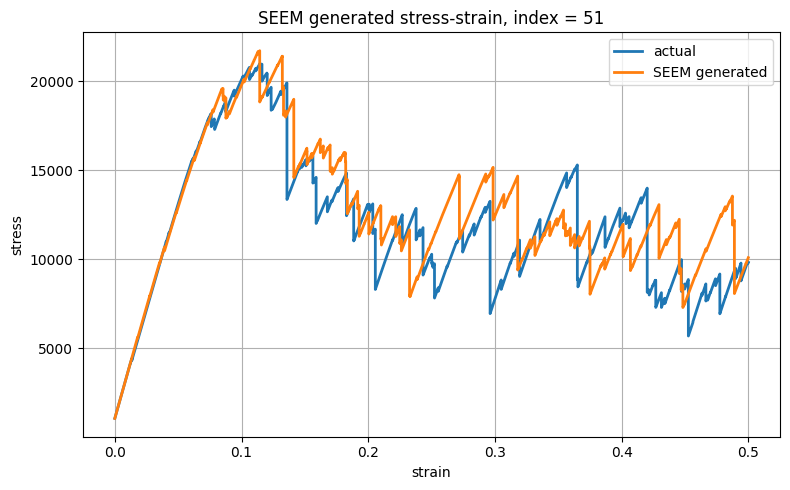

In [50]:
import matplotlib.pyplot as plt

# choose one real trajectory
traj_id = df["index"].iloc[0]

real_traj = df[df["index"] == traj_id].copy()
real_traj = real_traj.sort_values("strain_index")

pe0 = real_traj["pe"].values[0]
stress0 = real_traj["stress"].values[0]
N = len(real_traj)

print("Trajectory index:", traj_id)
print("N steps:", N)
print("Initial pe:", pe0)
print("Initial stress:", stress0)

trajpe_pred, trajstress_pred, avg_G = generate_single_trajectory_G_pred(
    pe0=pe0,
    stress0=stress0,
    N=N,
    event_dict=event_dict,
    non_event_dict=non_event_dict,
    event_probability=event_probability,
    u_edges=u_edges,
    tau_edges=tau_edges,
    tmp_dict=tmp_dict,
    dgamma=1e-5,
    u0=-4.60751861,
    seed=0,
    print_interval=10000
)

strain = real_traj["strain"].values
stress_actual = real_traj["stress"].values

plt.figure(figsize=(8, 5))
plt.plot(strain, stress_actual, label="actual", linewidth=2)
plt.plot(strain, trajstress_pred, label="SEEM generated", linewidth=2)

plt.xlabel("strain")
plt.ylabel("stress")
plt.title(f"SEEM generated stress-strain, index = {traj_id}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
import numpy as np
import pandas as pd

def generate_SEEM_dataset(
    df,
    n_traj_generate,
    N_steps=None,
    start_mode="real_initial",
    event_dict=None,
    non_event_dict=None,
    event_probability=None,
    u_edges=None,
    tau_edges=None,
    tmp_dict=None,
    dgamma=1e-5,
    u0=-4.60751861,
    seed=0,
    print_every_traj=10
):
    """
    Generate multiple SEEM trajectories and return a dataframe with columns:
        index, strain_index, strain, pe, stress

    start_mode:
        "real_initial" = sample initial conditions from real trajectories
    """

    rng = np.random.default_rng(seed)

    # Get real trajectory IDs
    traj_ids = df["index"].unique()

    generated_rows = []

    for j in range(n_traj_generate):

        if print_every_traj and j % print_every_traj == 0:
            print(f"Generating trajectory {j+1}/{n_traj_generate}")

        # ------------------------------------------------------------
        # Choose initial condition
        # ------------------------------------------------------------
        if start_mode == "real_initial":
            real_id = rng.choice(traj_ids)

            real_traj = df[df["index"] == real_id].copy()
            real_traj = real_traj.sort_values("strain_index")

            pe0 = real_traj["pe"].values[0]
            stress0 = real_traj["stress"].values[0]

            if N_steps is None:
                N = len(real_traj)
            else:
                N = N_steps

        else:
            raise ValueError("Only start_mode='real_initial' is currently implemented.")

        # ------------------------------------------------------------
        # Generate trajectory
        # ------------------------------------------------------------
        trajpe, trajstress, avg_G = generate_single_trajectory_G_pred(
            pe0=pe0,
            stress0=stress0,
            N=N,
            event_dict=event_dict,
            non_event_dict=non_event_dict,
            event_probability=event_probability,
            u_edges=u_edges,
            tau_edges=tau_edges,
            tmp_dict=tmp_dict,
            dgamma=dgamma,
            u0=u0,
            seed=seed + j,
            print_interval=None
        )

        strain_index = np.arange(N)
        strain = strain_index * dgamma

        gen_index = 10_000_000 + j  # synthetic trajectory IDs

        traj_df = pd.DataFrame({
            "index": gen_index,
            "strain_index": strain_index,
            "strain": strain,
            "pe": trajpe,
            "stress": trajstress,
            "source": "SEEM_generated"
        })

        generated_rows.append(traj_df)

    df_generated = pd.concat(generated_rows, ignore_index=True)

    return df_generated

In [52]:
df_generated = generate_SEEM_dataset(
    df=df,
    n_traj_generate=100,
    N_steps=None,  # same length as sampled real trajectory
    start_mode="real_initial",
    event_dict=event_dict,
    non_event_dict=non_event_dict,
    event_probability=event_probability,
    u_edges=u_edges,
    tau_edges=tau_edges,
    tmp_dict=tmp_dict,
    dgamma=1e-5,
    u0=-4.60751861,
    seed=0,
    print_every_traj=10
)

print(df_generated.shape)
df_generated.head()

Generating trajectory 1/100

Trajectory generation complete
Events: 218
No-events: 49780
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 284
No-events: 49714
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 429
No-events: 49569
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 253
No-events: 49745
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 348
No-events: 49650
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 264
No-events: 49734
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 393
No-events: 49605
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 317
No-events: 49681
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 268
No-events: 49730
Fallbacks: 0
Average G_pred used: 0.0

Trajectory generation complete
Events: 274
No-events: 49724
Fallbacks: 0
Average

,index,strain_index,strain,pe,stress,source
0,10000000,0,0.00000,-4.5953,944.912525,SEEM_generated
1,10000000,1,0.00001,-4.5953,947.278272,SEEM_generated
2,10000000,2,0.00002,-4.5953,949.775564,SEEM_generated
3,10000000,3,0.00003,-4.5953,950.946332,SEEM_generated
4,10000000,4,0.00004,-4.5953,953.478702,SEEM_generated


In [53]:
df_real_labeled = df.copy()
df_real_labeled["source"] = "real"

df_augmented = pd.concat(
    [df_real_labeled, df_generated],
    ignore_index=True
)

print("Real rows:", len(df_real_labeled))
print("Generated rows:", len(df_generated))
print("Augmented rows:", len(df_augmented))

Real rows: 42499150
Generated rows: 4999900
Augmented rows: 47499050


Rows used: 47498100
source
real              42498300
SEEM_generated     4999800
Name: count, dtype: int64

Most visited voxel in augmented data:
  u range:    0.02436970260561087 0.02574719011359148
  tau range:  1.0351853274580498 1.1432939926201269
  count:      1751901

Transitions from most visited voxel: 1751901
Event transitions from voxel: 8779
Stress-drop events from voxel: 8661

Delta plot limits:
  Delta u: (np.float64(-0.003143271757857633), np.float64(1.1306849134840036e-06))
  -Delta tau: (0.0, np.float64(0.190174456988074))


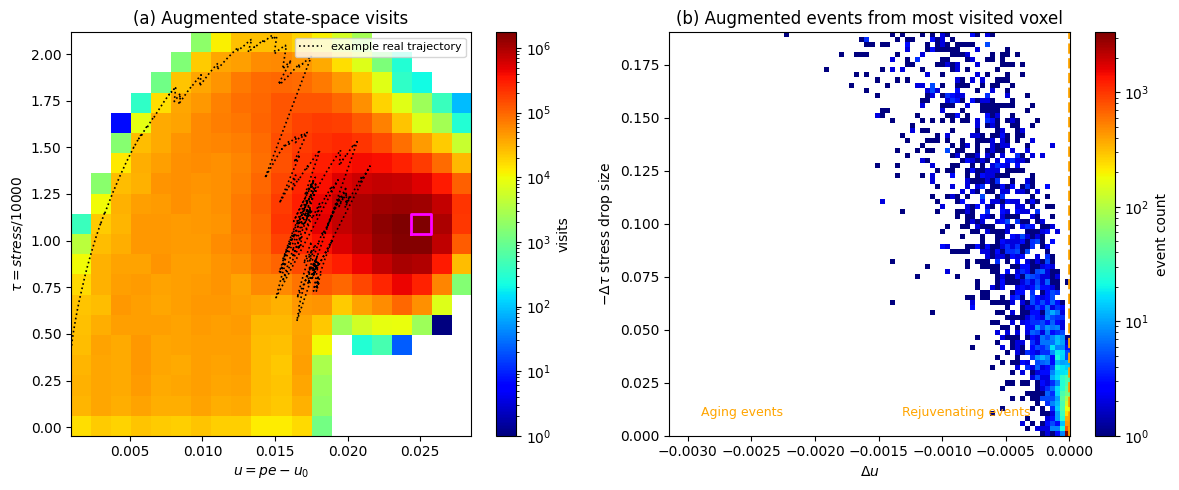

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

u0 = -4.60751861

n_u_bins = 20
n_tau_bins = 20

n_du_bins = 80
n_drop_bins = 80

# Use augmented data
df_heat = df_augmented.copy()

# Pick one real trajectory for overlay if possible
real_ids = df_heat.loc[df_heat["source"] == "real", "index"].unique()
traj_id = real_ids[0] if len(real_ids) > 0 else df_heat["index"].iloc[0]

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

df_fig_aug = df_heat.copy()
df_fig_aug = df_fig_aug.sort_values(["index", "strain_index"]).reset_index(drop=True)

df_fig_aug["u"] = df_fig_aug["pe"] - u0
df_fig_aug["tau"] = df_fig_aug["stress"] / 10000.0

# one-step transitions within each trajectory
df_fig_aug["u_next"] = df_fig_aug.groupby("index")["u"].shift(-1)
df_fig_aug["tau_next"] = df_fig_aug.groupby("index")["tau"].shift(-1)

df_fig_aug["du"] = df_fig_aug["u_next"] - df_fig_aug["u"]
df_fig_aug["dtau"] = df_fig_aug["tau_next"] - df_fig_aug["tau"]

df_fig_aug = df_fig_aug.dropna(subset=["u", "tau", "du", "dtau"]).copy()

print("Rows used:", len(df_fig_aug))
print(df_fig_aug["source"].value_counts())

# ------------------------------------------------------------
# Robust state-space limits
# ------------------------------------------------------------

u_xlim_state = (
    df_fig_aug["u"].quantile(0.001),
    df_fig_aug["u"].quantile(0.999)
)

tau_ylim_state = (
    df_fig_aug["tau"].quantile(0.001),
    df_fig_aug["tau"].quantile(0.999)
)

mask_state_window = (
    (df_fig_aug["u"] >= u_xlim_state[0]) &
    (df_fig_aug["u"] <= u_xlim_state[1]) &
    (df_fig_aug["tau"] >= tau_ylim_state[0]) &
    (df_fig_aug["tau"] <= tau_ylim_state[1])
)

df_state = df_fig_aug.loc[mask_state_window].copy()

# ------------------------------------------------------------
# Panel (a): augmented state-space visits
# ------------------------------------------------------------

visit_counts, u_edges_aug, tau_edges_aug = np.histogram2d(
    df_state["u"].values,
    df_state["tau"].values,
    bins=[n_u_bins, n_tau_bins],
    range=[
        [u_xlim_state[0], u_xlim_state[1]],
        [tau_ylim_state[0], tau_ylim_state[1]]
    ]
)

max_idx = np.unravel_index(np.argmax(visit_counts), visit_counts.shape)

u_bin_idx = max_idx[0]
tau_bin_idx = max_idx[1]

u_lo = u_edges_aug[u_bin_idx]
u_hi = u_edges_aug[u_bin_idx + 1]

tau_lo = tau_edges_aug[tau_bin_idx]
tau_hi = tau_edges_aug[tau_bin_idx + 1]

print()
print("Most visited voxel in augmented data:")
print("  u range:   ", u_lo, u_hi)
print("  tau range: ", tau_lo, tau_hi)
print("  count:     ", int(visit_counts[max_idx]))

# trajectory overlay
traj = df_fig_aug[df_fig_aug["index"] == traj_id].copy()
traj = traj.sort_values("strain_index")

# ------------------------------------------------------------
# Panel (b): event histogram from most visited augmented voxel
# ------------------------------------------------------------

mask_voxel = (
    (df_fig_aug["u"] >= u_lo) &
    (df_fig_aug["u"] < u_hi) &
    (df_fig_aug["tau"] >= tau_lo) &
    (df_fig_aug["tau"] < tau_hi)
)

df_voxel = df_fig_aug.loc[mask_voxel].copy()

df_events = df_voxel[(df_voxel["dtau"] < 0) | (df_voxel["du"] < 0)].copy()
df_events["stress_drop"] = -df_events["dtau"]

df_drop_events = df_events[df_events["stress_drop"] > 0].copy()

print()
print("Transitions from most visited voxel:", len(df_voxel))
print("Event transitions from voxel:", len(df_events))
print("Stress-drop events from voxel:", len(df_drop_events))

# Robust delta plot limits
du_xlim_delta = (
    df_drop_events["du"].quantile(0.001),
    df_drop_events["du"].quantile(0.999)
)

drop_ylim_delta = (
    0.0,
    df_drop_events["stress_drop"].quantile(0.95)
)

print()
print("Delta plot limits:")
print("  Delta u:", du_xlim_delta)
print("  -Delta tau:", drop_ylim_delta)

mask_delta_window = (
    (df_drop_events["du"] >= du_xlim_delta[0]) &
    (df_drop_events["du"] <= du_xlim_delta[1]) &
    (df_drop_events["stress_drop"] >= drop_ylim_delta[0]) &
    (df_drop_events["stress_drop"] <= drop_ylim_delta[1])
)

df_delta_plot = df_drop_events.loc[mask_delta_window].copy()

event_counts, du_edges_aug, drop_edges_aug = np.histogram2d(
    df_delta_plot["du"].values,
    df_delta_plot["stress_drop"].values,
    bins=[n_du_bins, n_drop_bins],
    range=[
        [du_xlim_delta[0], du_xlim_delta[1]],
        [drop_ylim_delta[0], drop_ylim_delta[1]]
    ]
)

# ------------------------------------------------------------
# Plot augmented Fig. 3(a,b)-style heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Panel (a): state-space visits
# -------------------------

ax = axes[0]

visit_plot = visit_counts.T.copy()
visit_plot[visit_plot == 0] = np.nan

im0 = ax.imshow(
    visit_plot,
    origin="lower",
    aspect="auto",
    extent=[
        u_edges_aug[0],
        u_edges_aug[-1],
        tau_edges_aug[0],
        tau_edges_aug[-1]
    ],
    cmap="jet",
    norm=LogNorm(vmin=1, vmax=np.nanmax(visit_plot))
)

ax.plot(
    traj["u"].values,
    traj["tau"].values,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="example real trajectory"
)

# mark most visited voxel
ax.plot(
    [u_lo, u_hi, u_hi, u_lo, u_lo],
    [tau_lo, tau_lo, tau_hi, tau_hi, tau_lo],
    color="magenta",
    linewidth=2
)

ax.set_xlim(u_xlim_state)
ax.set_ylim(tau_ylim_state)

ax.set_xlabel(r"$u = pe-u_0$")
ax.set_ylabel(r"$\tau = stress/10000$")
ax.set_title("(a) Augmented state-space visits")
ax.legend(loc="upper right", fontsize=8)

cbar0 = fig.colorbar(im0, ax=ax)
cbar0.set_label("visits")

# -------------------------
# Panel (b): jump distribution
# -------------------------

ax = axes[1]

event_plot = event_counts.T.copy()
event_plot[event_plot == 0] = np.nan

im1 = ax.imshow(
    event_plot,
    origin="lower",
    aspect="auto",
    extent=[
        du_edges_aug[0],
        du_edges_aug[-1],
        drop_edges_aug[0],
        drop_edges_aug[-1]
    ],
    cmap="jet",
    norm=LogNorm(vmin=1, vmax=np.nanmax(event_plot))
)

ax.axvline(0, color="orange", linestyle="--", linewidth=2)

ax.set_xlim(du_xlim_delta)
ax.set_ylim(drop_ylim_delta)

ax.set_xlabel(r"$\Delta u$")
ax.set_ylabel(r"$-\Delta \tau$ stress drop size")
ax.set_title("(b) Augmented events from most visited voxel")

# labels
y_text = drop_ylim_delta[0] + 0.05 * (drop_ylim_delta[1] - drop_ylim_delta[0])

ax.text(
    du_xlim_delta[0] + 0.08 * (du_xlim_delta[1] - du_xlim_delta[0]),
    y_text,
    "Aging events",
    color="orange",
    fontsize=9
)

ax.text(
    du_xlim_delta[0] + 0.58 * (du_xlim_delta[1] - du_xlim_delta[0]),
    y_text,
    "Rejuvenating events",
    color="orange",
    fontsize=9
)

cbar1 = fig.colorbar(im1, ax=ax)
cbar1.set_label("event count")

plt.tight_layout()
plt.show()